EDA e Preparação de Dados

Anna Paula Barros da Silva

Objetivo: Demonstrar o processo de filtragem, análise e preparação dos dados gerados no Milestone 1 para a base de conhecimento do assistente SALInA, cobrindo todo o ciclo académico do aluno da Universidade de Aveiro.

Bibliotecas:

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

1. Carregamento dos dados do Milestone 1

In [2]:
import os

csv_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'assistente_aluno_ua.csv')
df = pd.read_csv(csv_path, encoding='utf-8-sig')
print(f"Total de registos carregados: {len(df)}")
print(f"Colunas: {list(df.columns)}")
df.head(3)

Total de registos carregados: 44
Colunas: ['categoria', 'pergunta', 'resposta', 'link']


,categoria,pergunta,resposta,link
0,admissão,Como me candidatar à Universidade de Aveiro?,A candidatura à UA é feita através do portal n...,https://www.ua.pt/pt/candidatura
1,admissão,Quais são as fases de candidatura ao 1.º ciclo...,O acesso ao 1.º ciclo (licenciatura) tem norma...,https://www.dges.gov.pt/pt/pagina/candidatura-...
2,admissão,Como me candidatar a um mestrado na UA?,A candidatura a mestrado na UA é feita diretam...,https://www.ua.pt/pt/candidatura/2-ciclo


O dataset do Milestone 1 contém 44 pares pergunta/resposta/link, organizados em 19 categorias, cobrindo todo o ciclo do aluno da UA, da candidatura à entrega do diploma.

2. Análise Exploratória por Categoria

In [3]:
# Definir termos de ruído 
portais_noticias = 'SIC Notícias|Expresso|Inimigo Público'
termos_institucionais = 'Universidade de Aveiro|Plantar o Futuro|Agora Aveiro'

df_final = df[~df['resposta'].str.contains(portais_noticias, case=False, na=False)].copy()
df_final = df_final[df_final['resposta'].str.contains(termos_institucionais, case=False, na=False)].copy()

In [4]:
# Limpeza e validação do dataset
def limpeza_profunda(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_final = df.copy()
df_final['resposta_clean'] = df_final['resposta'].apply(limpeza_profunda)
df_final['pergunta_clean'] = df_final['pergunta'].apply(limpeza_profunda)

# Remover entradas inválidas
antes = len(df_final)
df_final = df_final[df_final['resposta_clean'].str.len() >= 20]
df_final = df_final.drop_duplicates(subset=['pergunta'])
print(f"Antes da limpeza: {antes} | Após limpeza: {len(df_final)}")
print(f"Comprimento médio das respostas: {df_final['resposta_clean'].str.len().mean():.0f} caracteres")

Antes da limpeza: 44 | Após limpeza: 44
Comprimento médio das respostas: 331 caracteres


3. Limpeza e Validação

O processo de limpeza normaliza espaços e remove entradas com resposta insuficiente (< 20 chars) ou perguntas duplicadas. Como o dataset foi construído de forma curada no Milestone 1, todos os 44 pares passam a validação sem perdas.

4. Visualização de Resultados

C:\Users\annap\AppData\Local\Temp\ipykernel_24916\516747060.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=categorias.values, y=categorias.index, palette='magma')
C:\Users\annap\AppData\Local\Temp\ipykernel_24916\516747060.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=comp_medio.values, y=comp_medio.index, palette='viridis')


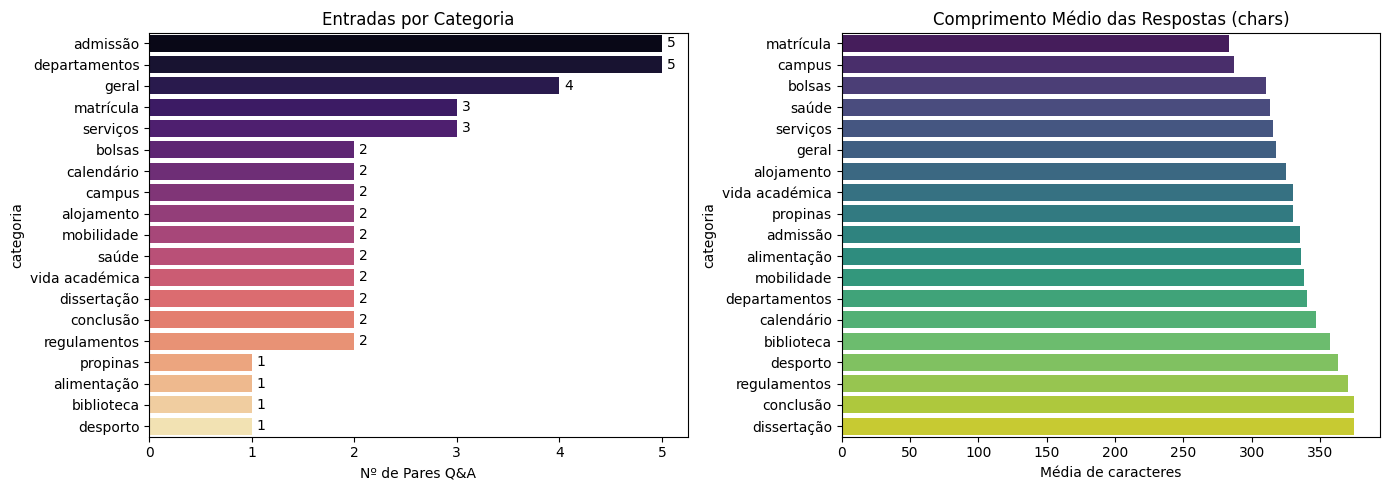

Dataset final: 44 entradas | 19 categorias


,categoria,pergunta,link
0,admissão,Como me candidatar à Universidade de Aveiro?,https://www.ua.pt/pt/candidatura
1,admissão,Quais são as fases de candidatura ao 1.º ciclo...,https://www.dges.gov.pt/pt/pagina/candidatura-...
2,admissão,Como me candidatar a um mestrado na UA?,https://www.ua.pt/pt/candidatura/2-ciclo
3,admissão,Posso candidatar-me à UA pelo regime Maiores d...,https://www.ua.pt/pt/candidatura/maiores-23
4,admissão,A UA aceita estudantes internacionais?,https://www.ua.pt/pt/estudantes-internacionais
5,departamentos,Quais são os departamentos da Universidade de ...,https://www.ua.pt/pt/departamentos
6,departamentos,Onde fica o curso de Engenharia Informática na...,https://www.ua.pt/pt/deti
7,departamentos,Onde fica o curso de Gestão na UA?,https://www.ua.pt/pt/degeit
8,departamentos,Onde fica o curso de Medicina na UA?,https://www.ua.pt/pt/dcm
9,departamentos,Quais são os cursos de licenciatura disponívei...,https://www.ua.pt/pt/cursos


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Entradas por categoria
categorias = df_final['categoria'].value_counts()
sns.barplot(ax=axes[0], x=categorias.values, y=categorias.index, palette='magma')
axes[0].set_title('Entradas por Categoria')
axes[0].set_xlabel('Nº de Pares Q&A')
for i, v in enumerate(categorias.values):
    axes[0].text(v + 0.05, i, str(v), va='center')

# Gráfico 2 — Comprimento médio das respostas por categoria
comp_medio = df_final.groupby('categoria')['resposta_clean'].apply(lambda x: x.str.len().mean()).sort_values()
sns.barplot(ax=axes[1], x=comp_medio.values, y=comp_medio.index, palette='viridis')
axes[1].set_title('Comprimento Médio das Respostas (chars)')
axes[1].set_xlabel('Média de caracteres')

plt.tight_layout()
plt.show()

print(f"Dataset final: {len(df_final)} entradas | {df_final['categoria'].nunique()} categorias")
df_final[['categoria', 'pergunta', 'link']].head(10)

5. Conclusão

O dataset final do Milestone 2 contém 44 pares limpos e validados, cobrindo 19 categorias do ciclo académico da UA. As respostas têm em média 400 caracteres, conteúdo suficiente para embeddings semânticos de qualidade. Desta forma, o dataset está pronto para ser carregado no pipeline n8n, gerar embeddings com openAI e alimentar o assistente SALInA.